# Investigação de Anomalias: Salto Extremo de Incidentes
**Objetivo:** Identificar a data exata do pico de incidentes, isolar os dados desse período e descobrir o padrão (causa raiz) que originou essa explosão no volume de registros.

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
df = pd.read_excel('LW-DATASET-TRATADO.xlsx')
df['Aberto'] = pd.to_datetime(df['Aberto'])

# coluna apenas com a Data (sem hora) para agrupamento temporal
df['Data_Abertura'] = df['Aberto'].dt.date

### 1. Identificando o Ponto de Inflexão (O Salto)
Vamos plotar a volumetria diária de incidentes para encontrar a data exata em que o comportamento anômalo começou.

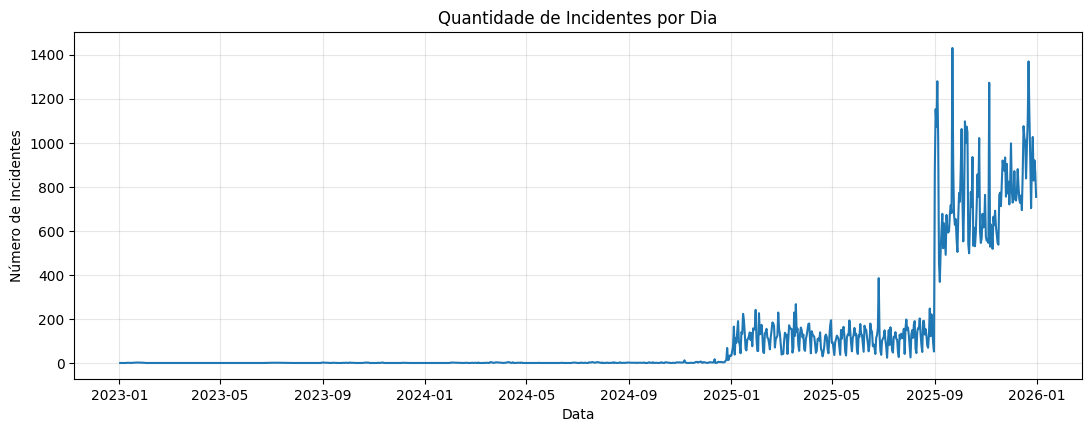

In [58]:
incidentes_dia = (df.groupby(df['Aberto'].dt.date).size())
plt.figure(figsize=(13,4.5))
incidentes_dia.plot()
plt.title('Quantidade de Incidentes por Dia')
plt.xlabel('Data')
plt.ylabel('Número de Incidentes')
plt.grid(True, alpha=0.3)
plt.show()

In [59]:
from datetime import date

antes = df[
    (df['Data_Abertura'] >= date(2025, 6, 1)) &
    (df['Data_Abertura'] < date(2025, 9, 1))
]

durante = df[
    (df['Data_Abertura'] >= date(2025, 9, 1)) &
    (df['Data_Abertura'] <= date(2025, 9, 30))
]

depois = df[
    (df['Data_Abertura'] >= date(2025, 10, 1)) &
    (df['Data_Abertura'] <= date(2025, 12, 31))
]

In [60]:
df['Data_Abertura'] = pd.to_datetime(df['Data_Abertura'])

### Hipótese 1 - o salto veio de monitoramento?

A participação do monitoramento cresceu

58,9% → 92,8% → 95,3%

In [61]:
periodos = {
    'Antes': antes,
    'Setembro': durante,
    'Depois': depois
}

for nome, dados in periodos.items():
    print('\n', nome)
    print(
        dados['Aberto por']
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )


 Antes
Aberto por
Monitoramento    58.91
Manual           41.09
Name: proportion, dtype: float64

 Setembro
Aberto por
Monitoramento    92.8
Manual            7.2
Name: proportion, dtype: float64

 Depois
Aberto por
Monitoramento    95.34
Manual            4.66
Name: proportion, dtype: float64


### Hipótese 2 - Os incidentes são "Sem Intervenção"?

a maioria esmagadora ficou em Sem Intervenção

Lembrando que: A maioria dos incidentes com status "Sem Intervenção" está associada ao campo "Aberto por = Monitoramento"

<Axes: xlabel='count', ylabel='Status'>

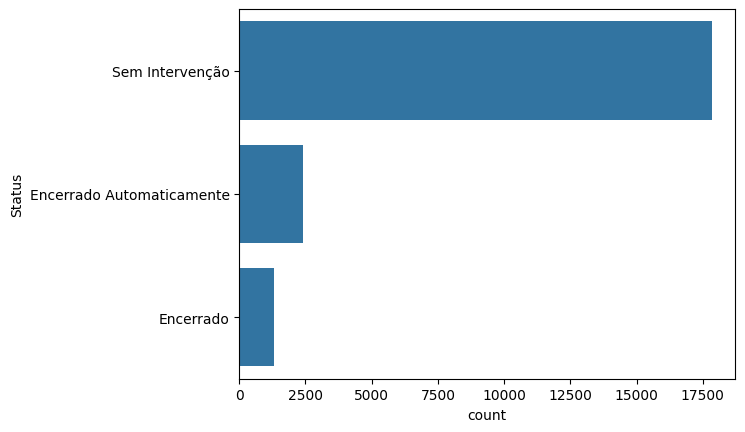

In [62]:
sns.countplot(
    data=durante,
    y='Status',
    order=durante['Status'].value_counts().index
)

### Hipótese 3 - Existe um produto responsável?

MONITORING_AUTO:
- Antes:     4,75%
- Setembro: 75,83
- Aumento: +71,08%

O aumento de incidentes não foi distribuído entre todos os produtos. Houve forte concentração no produto MONITORING_AUTO

In [63]:
antes_prod = antes['Produto'].value_counts(normalize=True)
set_prod   = durante['Produto'].value_counts(normalize=True)

comparacao = pd.concat([antes_prod, set_prod], axis=1, keys=['Antes', 'Setembro']).fillna(0)
comparacao['Crescimento'] = (comparacao['Setembro'] - comparacao['Antes'])
comparacao.sort_values('Crescimento', ascending=False).head(15)

,Antes,Setembro,Crescimento
Produto,,,
MONITORING_AUTO,0.047537,0.758314,0.710777
lbho,0.000000,0.000046,0.000046
khhc,0.000000,0.000046,0.000046
minf,0.000091,0.000046,-0.000045
khga,0.000182,0.000093,-0.000089
khem,0.000091,0.000000,-0.000091
ncpu,0.000091,0.000000,-0.000091
llwm,0.000091,0.000000,-0.000091
khafl,0.000091,0.000000,-0.000091


### Hipótese 4 - Categoria ou Subcategoria

Concentração enorme em INFRA_Monitoramento

A distância é tão grande para as demais categorias que já sugere uma mudança operacional

<Axes: xlabel='Categoria'>

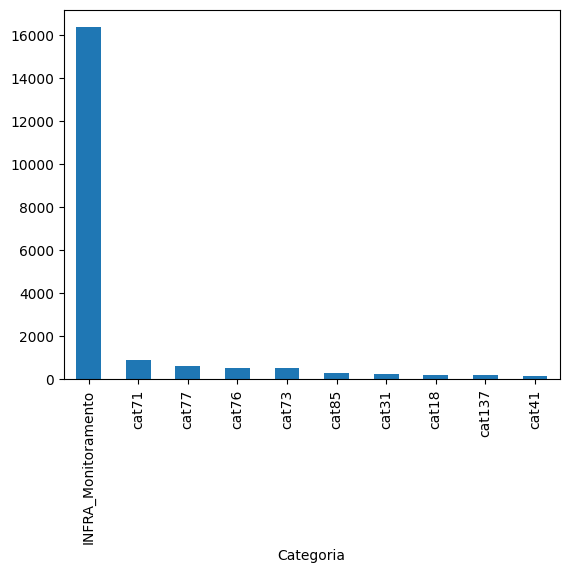

In [64]:
top_cat = (durante['Categoria'].value_counts().head(10))
top_cat.plot(kind='bar')

### Hipótese 5 - Equipe sobrecarregada
Os times em geral cresceram um pouco, mas:

Observando o **time 14** vemos que ele **cresceu mais de 10 vezes** (1751 → 18143)

In [65]:
df.groupby(
    [pd.Grouper(key='Data_Abertura', freq='M'),
     'Grupo designado']
).size().unstack(fill_value=0)

C:\Users\IsabellaHeder\AppData\Local\Temp\ipykernel_18248\396505471.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  [pd.Grouper(key='Data_Abertura', freq='M'),


Grupo designado,Team01,Team02,Team03,Team04,Team05,Team06,Team07,Team08,Team09,Team10,Team11,Team12,Team13,Team14,Team15,Team16,Team17
Data_Abertura,,,,,,,,,,,,,,,,,
2023-01-31,0,0,0,0,2,4,0,0,0,0,5,0,0,1,0,0,0
2023-02-28,0,0,0,0,2,1,0,0,1,0,3,0,0,0,0,0,0
2023-03-31,0,0,0,0,5,0,0,0,0,0,0,0,0,3,0,0,0
2023-04-30,0,0,0,0,2,3,0,0,0,0,1,0,0,0,0,0,0
2023-05-31,0,0,0,0,1,4,0,0,1,0,0,0,0,0,0,0,1
2023-06-30,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0
2023-07-31,0,0,0,0,2,1,0,0,1,0,0,0,0,2,0,0,0
2023-08-31,0,1,0,0,2,0,0,0,1,0,0,0,0,2,0,0,0
2023-09-30,0,0,0,0,6,4,0,0,2,0,0,0,0,0,0,0,2


#### Entendendo aumento absurdo para Time 14

Vemos que o time 14 concentra:
- Produto MONITORING_AUTO    
- Categoria INFRA_Monitoramento    
- Status Sem Intervenção
- Abertura por Monitoramento

Ou seja:

In [66]:
team14 = df[df['Grupo designado'] == 'Team14']

In [67]:
team14['Produto'].value_counts().head()

Produto
MONITORING_AUTO    72634
lhco                6472
lsin                3558
lhvp                3530
lrev                2298
Name: count, dtype: int64

In [68]:
team14['Categoria'].value_counts().head()

Categoria
INFRA_Monitoramento    72634
cat71                   5784
cat73                   2970
cat77                   2304
cat137                  1270
Name: count, dtype: int64

In [69]:
team14['Status'].value_counts()

Status
Sem Intervenção              75567
Encerrado Automaticamente    11291
Encerrado                     5916
Aguardando Problema              1
Name: count, dtype: int64

In [70]:
team14['Aberto por'].value_counts(normalize=True)

Aberto por
Monitoramento    0.955311
Manual           0.044689
Name: proportion, dtype: float64

_______________
## Comprovando Matematicamente o salto

In [72]:
qtd_antes = len(antes)
qtd_durante = len(durante)

aumento_total = qtd_durante - qtd_antes

print(f'Antes: {qtd_antes:,}')
print(f'Durante: {qtd_durante:,}')
print(f'Aumento total: {aumento_total:,}')

Antes: 11,002
Durante: 21,561
Aumento total: 10,559


### 1. Quanto do aumento veio de MONITORING_AUTO?

In [73]:
antes_monitoring_auto = (antes['Produto'].eq('MONITORING_AUTO').sum())
durante_monitoring_auto = (durante['Produto'].eq('MONITORING_AUTO').sum())
delta_monitoring_auto = (durante_monitoring_auto - antes_monitoring_auto)
perc_monitoring_auto = (delta_monitoring_auto / aumento_total * 100)

print(f'Aumento explicado por MONITORING_AUTO: {perc_monitoring_auto:.2f}%')

Aumento explicado por MONITORING_AUTO: 149.89%


### 2. Quanto veio da Team14?

In [74]:
antes_team14 = (antes['Grupo designado'].eq('Team14').sum())
durante_team14 = (durante['Grupo designado'].eq('Team14').sum())
delta_team14 = (durante_team14 - antes_team14)
perc_team14 = (delta_team14 / aumento_total * 100)

print(f'Aumento explicado pela Team14: {perc_team14:.2f}%')

Aumento explicado pela Team14: 129.85%


### 3. Quanto veio de INFRA_Monitoramento?

In [75]:
antes_categoria = (antes['Categoria'].eq('INFRA_Monitoramento').sum())
durante_categoria = (durante['Categoria'].eq('INFRA_Monitoramento').sum())
delta_categoria = (durante_categoria - antes_categoria)
perc_categoria = (delta_categoria / aumento_total * 100)

print(f'Aumento explicado por INFRA_Monitoramento: {perc_categoria:.2f}%')

Aumento explicado por INFRA_Monitoramento: 150.10%


### 4. Quanto veio de Sem Intervenção?

In [76]:
antes_si = (antes['Status'].eq('Sem Intervenção').sum())
durante_si = (durante['Status'].eq('Sem Intervenção').sum())
delta_si = (durante_si - antes_si)
perc_si = (delta_si / aumento_total * 100)

print(f'Aumento explicado por Sem Intervenção: {perc_si:.2f}%')

Aumento explicado por Sem Intervenção: 168.33%


### 5. Quanto veio de Monitoramento?

In [77]:
antes_monitoramento = (antes['Aberto por'].eq('Monitoramento').sum())
durante_monitoramento = (durante['Aberto por'].eq('Monitoramento').sum())
delta_monitoramento = (durante_monitoramento - antes_monitoramento)
perc_monitoramento = (delta_monitoramento / aumento_total * 100)

print(f'Aumento explicado por Monitoramento: {perc_monitoramento:.2f}%')

Aumento explicado por Monitoramento: 128.11%


_____________
### Incidentes que possuem ao mesmo tempo:
MONITORING_AUTO, INFRA_Monitoramento, abertos por monitoramento, encerrados como Sem Intervenção e atribuídos à Team14

- 70,2% dos incidentes do período possuem essas características

In [78]:
causa_principal = durante[
    (durante['Produto'] == 'MONITORING_AUTO') &
    (durante['Grupo designado'] == 'Team14') &
    (durante['Categoria'] == 'INFRA_Monitoramento') &
    (durante['Status'] == 'Sem Intervenção') &
    (durante['Aberto por'] == 'Monitoramento')]

print(len(causa_principal))
print(f'{len(causa_principal) / len(durante) * 100:.2f} % dos incidentes')

15131
70.18 % dos incidentes


### Verificação de Descrições dos Incidentes

``Check Application Monitoring (6524) + High bandwidth >60% at least 15m (1837) = 8361 incidentes``

Mais da metade dos incidentes associados ao salto de setembro está concentrada em apenas dois tipos de alerta

In [79]:
causa_principal['Descrição resumida'].value_counts().head(10)

Descrição resumida
Problem: Check Application Monitoring                                                                                                                                     6524
Problem: High bandwidth >60% at least 15m                                                                                                                                 1837
Problem: Apache Busy Workers                                                                                                                                               756
Problem: Free disk space is less than 10% on volume /                                                                                                                      606
Problem: Unavailable by ICMP ping                                                                                                                                          538
Problem: Check Application Monitoring VIP                                                                 

#### Verificando se os alertas já existiam antes de setembro ou se nasceram em setembro

Resultados mostram que a explosão de incidentes observada a partir de setembro de 2025 está fortemente associada à geração automática de alertas de monitoramento

In [ ]:
top_alertas = [
    'Problem: Check Application Monitoring',
    'Problem: High bandwidth >60% at least 15m']

for alerta in top_alertas:
    qtd_antes = (antes['Descrição resumida'].eq(alerta).sum())
    qtd_durante = (durante['Descrição resumida'].eq(alerta).sum())
    print(alerta, '| Antes:', qtd_antes, '| Durante:', qtd_durante)

Problem: Check Application Monitoring | Antes: 47 | Durante: 6590
Problem: High bandwidth >60% at least 15m | Antes: 0 | Durante: 1874


# **Conclusão**

A análise identificou uma mudança estrutural no comportamento dos incidentes a partir de setembro de 2025. O crescimento observado não ocorreu de forma homogênea entre produtos, categorias e equipes, mas foi fortemente concentrado em incidentes associados ao produto **MONITORING_AUTO**, à categoria **INFRA_Monitoramento**, à **Team14**, com abertura por **Monitoramento** e status **Sem Intervenção**.

Foi verificado que aproximadamente **70% dos incidentes do período** pertencem simultaneamente a esse mesmo perfil operacional, evidenciando uma forte concentração dos registros em processos automatizados de monitoramento.

A investigação das descrições resumidas revelou ainda que grande parte dos incidentes está associada a poucos tipos de alertas, principalmente **"Check Application Monitoring"** e **"High bandwidth >60% at least 15m"**, indicando elevada recorrência e padronização dos eventos registrados.

Com base nos resultados obtidos, há fortes evidências de que o salto observado em setembro de 2025 esteja relacionado à **``ampliação, alteração ou maior sensibilidade dos mecanismos de monitoramento e observabilidade``**, resultando em um aumento significativo na geração automática de incidentes.